# SMS Spam Detection using Natural Language Processing

## Objective
Build a machine learning model capable of classifying SMS messages as Spam or Ham (Normal).

## Dataset
SMS Spam Collection Dataset

## Techniques Used
- Text Processing
- TF-IDF Vectorization
- Naive Bayes
- Random Forest
- Model Evaluation

## Libraries
- Pandas
- NumPy
- Scikit-Learn
- Matplotlib
- Seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, encoding="latin-1", sep='\t', header=None)
df.columns = ["Label", "Message"]

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5572, 2)


,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
print(df["Label"].value_counts())

spam_count = (df["Label"] == "spam").sum()
ham_count = (df["Label"] == "ham").sum()

print("\nSpam Messages:", spam_count)
print("Ham Messages:", ham_count)

Label
ham     4825
spam     747
Name: count, dtype: int64

Spam Messages: 747
Ham Messages: 4825


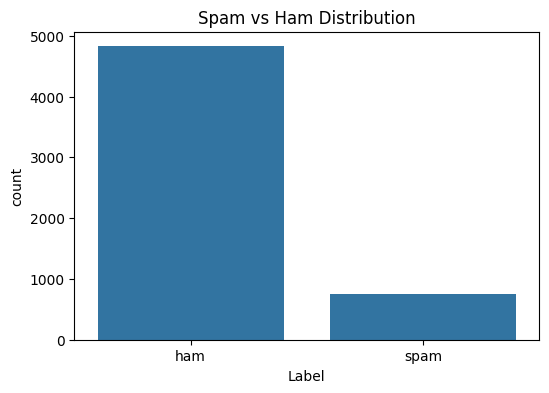

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Label", data=df)

plt.title("Spam vs Ham Distribution")
plt.show()

In [8]:
df["Length"] = df["Message"].apply(len)

print(df.groupby("Label")["Length"].describe())

        count        mean        std   min    25%    50%    75%    max
Label                                                                 
ham    4825.0   71.558964  58.459702   2.0   33.0   52.0   93.0  910.0
spam    747.0  139.119143  28.998900  13.0  133.0  149.0  158.0  224.0


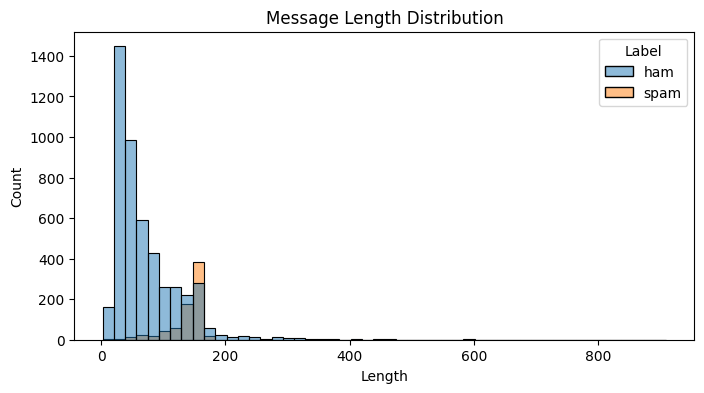

In [9]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="Length",
    hue="Label",
    bins=50
)

plt.title("Message Length Distribution")
plt.show()

In [10]:
df["Label_Encoded"] = (df["Label"] == "spam").astype(int)

X = df["Message"]
y = df["Label_Encoded"]

print(X.shape)
print(y.shape)

(5572,)
(5572,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4457
Testing Samples: 1115


In [12]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (4457, 5000)
Testing Shape: (1115, 5000)


In [13]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9820627802690582


In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9811659192825112


In [15]:
print("=" * 40)
print("MODEL COMPARISON")
print("=" * 40)

print("Naive Bayes:", nb_accuracy)
print("Random Forest:", rf_accuracy)

MODEL COMPARISON
Naive Bayes: 0.9820627802690582
Random Forest: 0.9811659192825112


In [16]:
if nb_accuracy > rf_accuracy:
    best_pred = nb_pred
    best_name = "Naive Bayes"
else:
    best_pred = rf_pred
    best_name = "Random Forest"

print("Best Model:", best_name)

Best Model: Naive Bayes


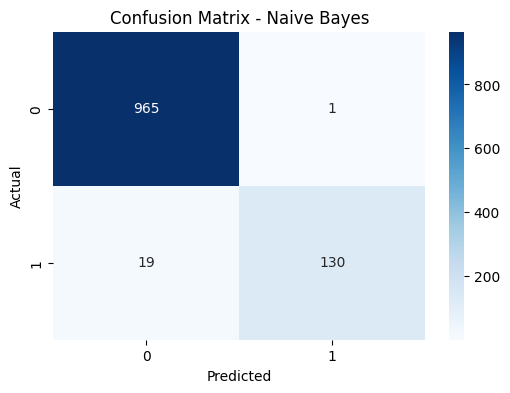

In [17]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [19]:
messages = [
    "Congratulations! You won a free iPhone",
    "Hey, where are you?",
    "URGENT! Claim your prize now",
    "Let's meet at 5 PM"
]

for msg in messages:
    msg_vector = vectorizer.transform([msg])

    prediction = nb_model.predict(msg_vector)[0]

    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"

    print("\nMessage:", msg)
    print("Prediction:", result)
    print("-" * 50)


Message: Congratulations! You won a free iPhone
Prediction: SPAM
--------------------------------------------------

Message: Hey, where are you?
Prediction: HAM
--------------------------------------------------

Message: URGENT! Claim your prize now
Prediction: SPAM
--------------------------------------------------

Message: Let's meet at 5 PM
Prediction: HAM
--------------------------------------------------
